In [1]:
import matplotlib.pyplot as plt
import torch

from pi_solvers import sde_lib, solver_lib, utils

torch.manual_seed(42)

In [2]:
edm = solver_lib.get_edm_schedule(25)
edm < 1

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True])

In [3]:
model, encoder = utils.load_edm_checkpoint("../model/edm2-img64-xl-0671088-0.040.pkl")
model = model.to("cuda")

In [4]:
x = torch.zeros((16, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((1,)).to("cuda")
noise = torch.randn_like(x) * 80

In [5]:
labels = torch.eye(model.label_dim, device="cuda")[torch.randint(high=model.label_dim, size=(16,), device="cuda")]

In [6]:
sigma_min = 0.002
sigma_max = 80

sde_ = sde_lib.EDMSDE(ode=False).to("cuda")
rsde = sde_.get_reverse_sde(model).to("cuda")

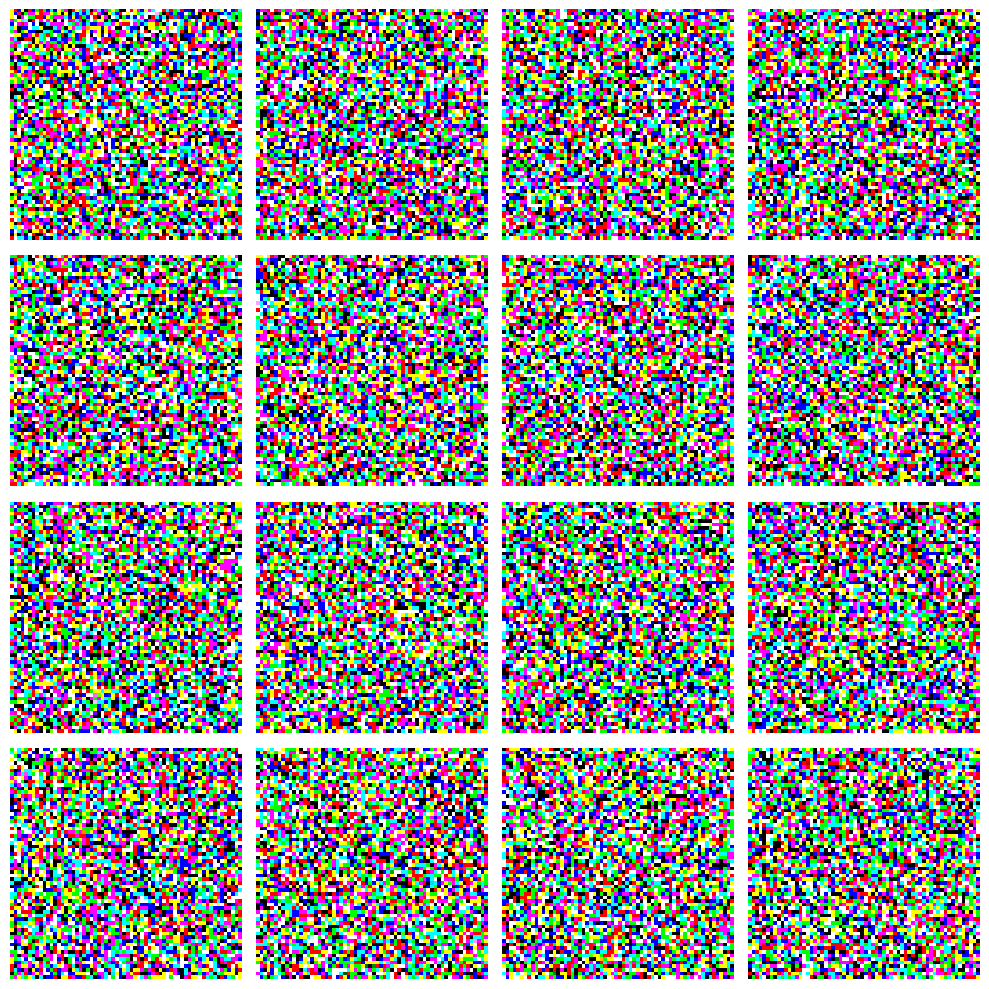

In [7]:
images = encoder.decode(noise).permute(0, 2, 3, 1)

def plot_images(images):
    fig, axes = plt.subplots(4, 4)
    fig.set_size_inches(10, 10)
    
    for i in range(4):
        for j in range(4):
            axes[i][j].imshow(images[i * 4 + j])
            axes[i][j].axis("off")
            
    fig.tight_layout()
    
plot_images(images.cpu())

In [8]:
n_steps = 75
rho = 7
# From EDM2 code
# discretisation = solver_lib.get_edm_schedule(n_steps, sigma_min, sigma_max, rho)
# discretisation = solver_lib.get_entropy_schedule(n_steps, entropy_checkpoint="../refs/img64_rescaled_entropic_time.pt")
discretisation = solver_lib.get_pi_schedule(20, 5, "../data/image_testing/pi_2/75NFE_2/data/_t.csv")

In [57]:
discretisation

tensor([8.0000e+01, 7.4172e+01, 6.8706e+01, 6.3582e+01, 5.8783e+01, 5.4314e+01,
        5.0135e+01, 4.6230e+01, 4.2584e+01, 3.9199e+01, 3.6045e+01, 3.3106e+01,
        3.0372e+01, 2.7842e+01, 2.5494e+01, 2.3315e+01, 2.1294e+01, 1.9432e+01,
        1.7710e+01, 1.6119e+01, 1.4649e+01, 1.3300e+01, 1.2059e+01, 1.0917e+01,
        9.8670e+00, 8.9076e+00, 8.0298e+00, 7.2258e+00, 6.4906e+00, 5.8222e+00,
        5.2143e+00, 4.6607e+00, 4.1573e+00, 3.7023e+00, 3.2913e+00, 2.9193e+00,
        2.5833e+00, 2.2817e+00, 2.0113e+00, 1.7683e+00, 1.5505e+00, 1.3565e+00,
        1.1841e+00, 1.0305e+00, 8.9398e-01, 7.7344e-01, 6.6748e-01, 5.7399e-01,
        4.9176e-01, 4.1990e-01, 3.5750e-01, 3.0309e-01, 2.5582e-01, 2.1502e-01,
        1.8012e-01, 1.5011e-01, 1.2441e-01, 1.0258e-01, 8.4233e-02, 6.8729e-02,
        5.5696e-02, 4.4830e-02, 3.5906e-02, 2.8525e-02, 2.2463e-02, 1.7531e-02,
        1.3596e-02, 1.0433e-02, 7.9116e-03, 5.9254e-03, 4.4019e-03, 3.2221e-03,
        2.3202e-03, 2.0000e-03, 0.0000e+

In [58]:
rsde.reset()

em_solver = solver_lib.EulerMarayumaSolver(rsde, discretisation).to("cuda")

x_em = em_solver.solve(noise.clone(), labels)

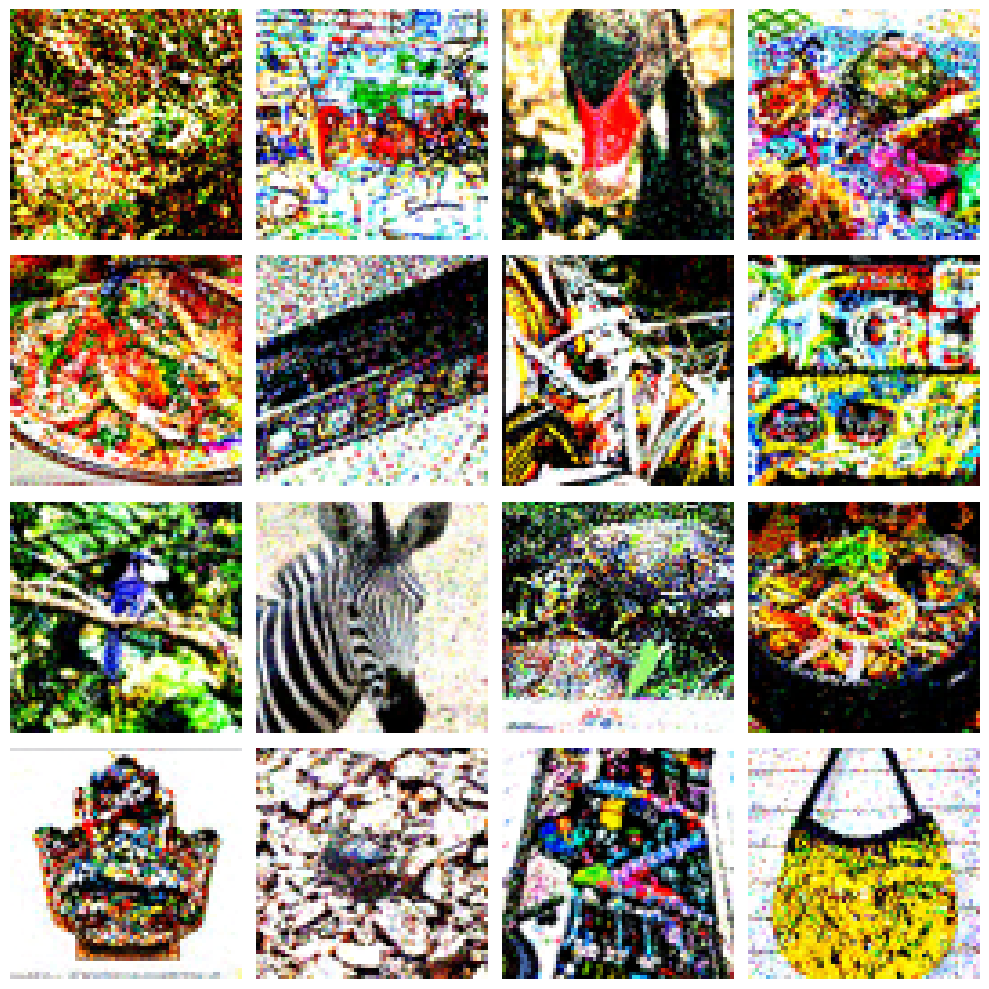

In [59]:
images = encoder.decode(x_em).permute(0, 2, 3, 1)

plot_images(images.cpu())

In [9]:
sigmas = []
sigmas_std = []
trajectories = []
def pi_callback(x, t, h, error):    
    print(f"sigma = {torch.mean(t)}", end=" ")
    print(f"h = {torch.mean(h)}", end=" ")
    print(f"error = {torch.mean(error)}")
    sigmas.append(torch.mean(t).cpu())
    sigmas_std.append(torch.std(t).cpu())
    trajectories.append(t[0:2].clone())

In [10]:
sigmas = [80]
sigmas_std = [0]

rsde.reset()

pi_solver = solver_lib.construct_heun_end_adaptive_solver(
    solver_lib.PISolver,
    rsde,
    ode_threshold=0.05,
    n_ode_steps=5,
    ki=0.3,
    kp=0.1, 
    tau_a=0.06,
    tau_r=18,
    alpha=0.9,
    h_start=45,
    max_decrease=0.2,
    max_increase=5,
    interval=(80, 0.002),
    abs_error=False,
    batch_norm=False
).to("cuda")

x_pi = pi_solver.solve(noise.clone(), labels, callback=pi_callback)

sigma = 35.0 h = -14.490992546081543 error = 0.9176698327064514
sigma = 20.50900650024414 h = -7.970895290374756 error = 0.4885942041873932
sigma = 12.538111686706543 h = -4.463723659515381 error = 0.3990910053253174
sigma = 8.07438850402832 h = -2.681234121322632 error = 0.31843093037605286
sigma = 5.393154144287109 h = -1.6834932565689087 error = 0.26939284801483154
sigma = 3.709660530090332 h = -1.0964974164962769 error = 0.23572561144828796
sigma = 2.6131632328033447 h = -0.7381735444068909 error = 0.2099197804927826
sigma = 1.8749897480010986 h = -0.5101841688156128 error = 0.19094055891036987
sigma = 1.3648054599761963 h = -0.36068570613861084 error = 0.1762215942144394
sigma = 1.004119873046875 h = -0.25978609919548035 error = 0.1648620367050171
sigma = 0.7443337440490723 h = -0.18962858617305756 error = 0.15681031346321106
sigma = 0.5547051429748535 h = -0.14048397541046143 error = 0.14923690259456635
sigma = 0.4142211973667145 h = -0.10498400777578354 error = 0.144236251711845

In [11]:
rsde.nfe / 16

49.25

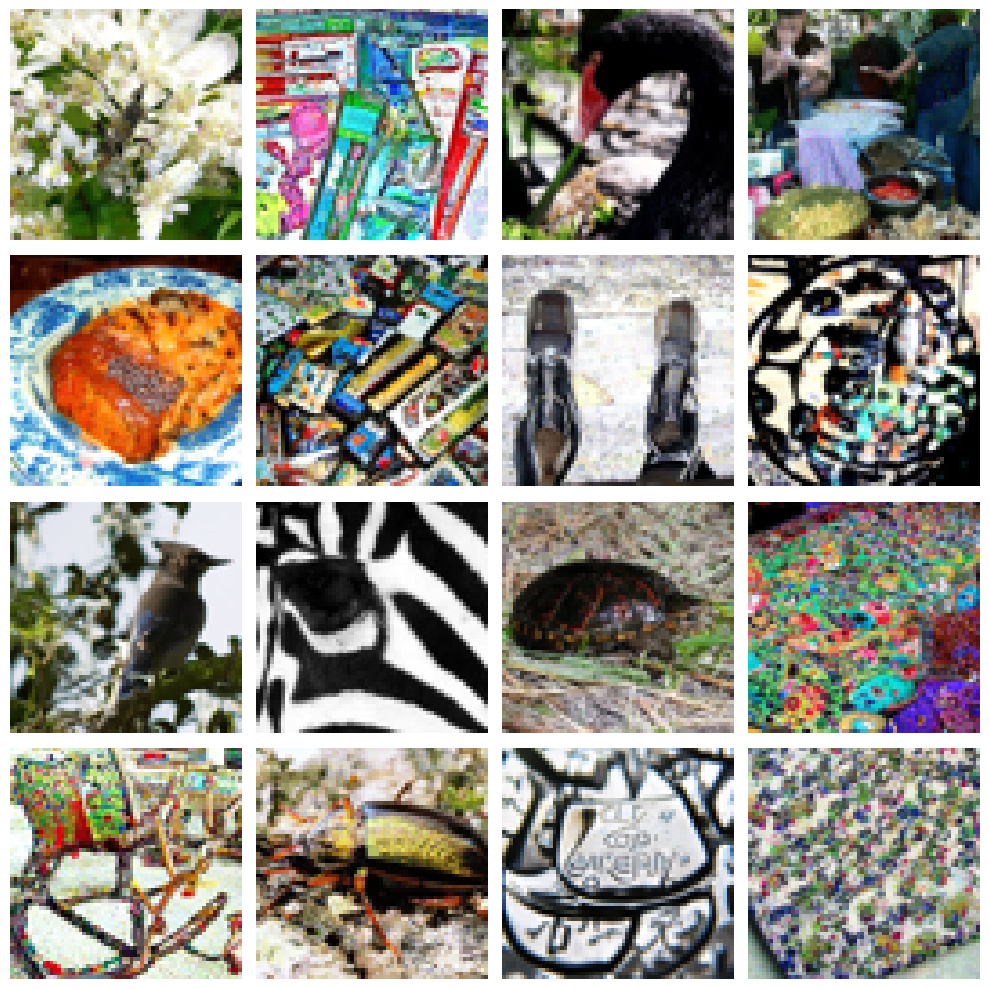

In [12]:
images = encoder.decode(x_pi).permute(0, 2, 3, 1)
plot_images(images.cpu())

In [13]:
sigmas = [80]
sigmas_std = [0]
trajectories = []

rsde.reset()

ggf_solver = solver_lib.construct_heun_end_adaptive_solver(
    solver_lib.GottaGoFast,
    rsde,
    ode_threshold=0.05,
    n_ode_steps=5,
    tau_a=0.0078,   # Range is -1, 1, which is mentioned in paper to correspond to a tau_a of (1 -- 1 / 256 = 0.0078)
    tau_r=24.5,
    h_start=25,
    r=0.1,
    alpha=0.7,
    interval=(80, 0.002)
).to("cuda")

x_ggf = ggf_solver.solve(noise.clone(), labels, pi_callback)

sigma = 55.0 h = -19.415489196777344 error = 0.3539227843284607
sigma = 35.584510803222656 h = -14.12447738647461 error = 0.6855530142784119
sigma = 25.88231658935547 h = -9.847463607788086 error = 1.309314250946045
sigma = 22.912254333496094 h = -6.888328552246094 error = 1.3698618412017822
sigma = 16.93520736694336 h = -5.145056247711182 error = 0.6043568849563599
sigma = 11.790153503417969 h = -3.9233248233795166 error = 0.4621601104736328
sigma = 8.094215393066406 h = -2.9145898818969727 error = 0.6841020584106445
sigma = 6.527488708496094 h = -2.1104001998901367 error = 0.9668662548065186
sigma = 4.846859931945801 h = -1.5634231567382812 error = 0.6758662462234497
sigma = 3.3703508377075195 h = -1.1806561946868896 error = 0.5369836091995239
sigma = 2.340519428253174 h = -0.8656793236732483 error = 0.6880007982254028
sigma = 1.8468809127807617 h = -0.6135271191596985 error = 1.0941871404647827
sigma = 1.30655837059021 h = -0.4513375759124756 error = 0.6707204580307007
sigma = 0.954

In [14]:
rsde.nfe / 16

49.75

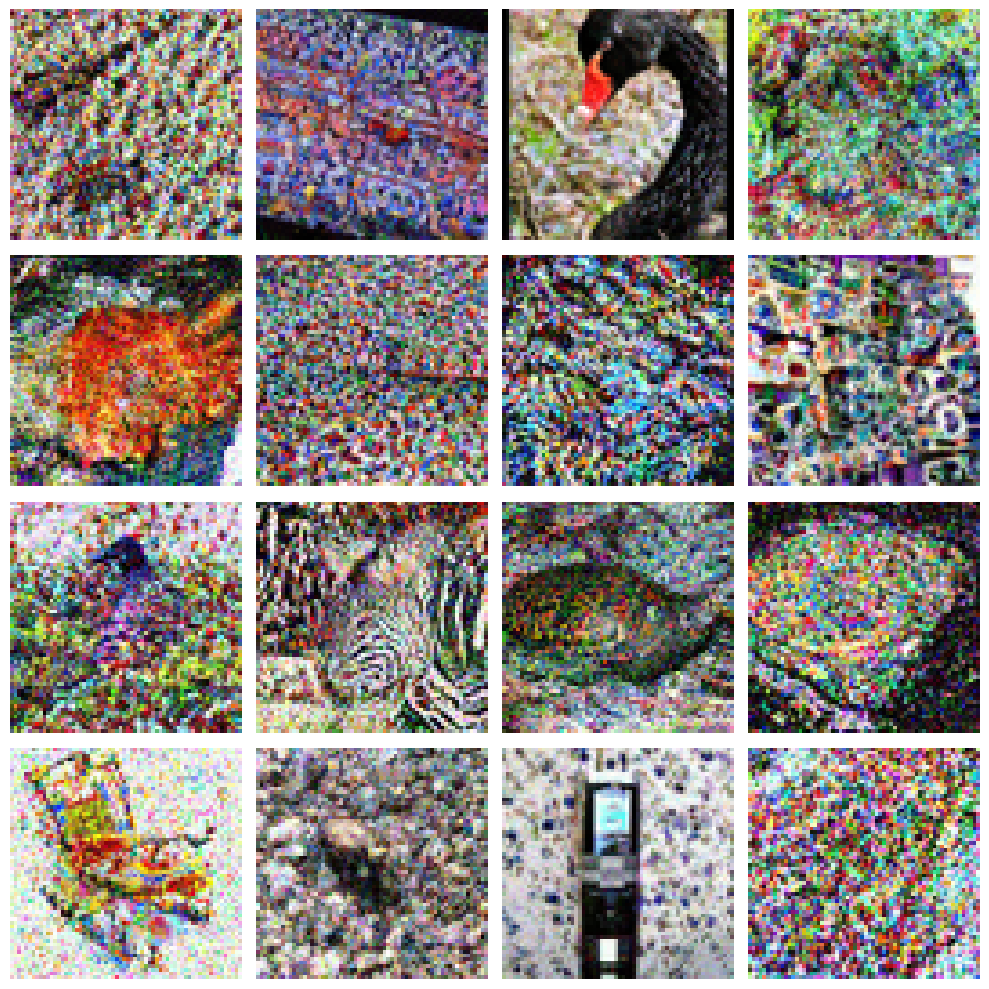

In [15]:
images = encoder.decode(x_ggf).permute(0, 2, 3, 1)
plot_images(images.cpu())

In [26]:
edm_schedule = solver_lib.get_edm_schedule(100)

In [27]:
trajectory_1 = []
trajectory_2 = []
for element in trajectories:
    trajectory_1.append(element[0, 0, 0])
    trajectory_2.append(element[1, 0, 0])

trajectory_1 = torch.cat(trajectory_1)
trajectory_2 = torch.cat(trajectory_2)

trajectory_1 = trajectory_1[trajectory_1 > 0.05]
trajectory_2 = trajectory_2[trajectory_2 > 0.05]
discretisation = discretisation[discretisation > 0.05]
edm_schedule = edm_schedule[edm_schedule > 0.05]

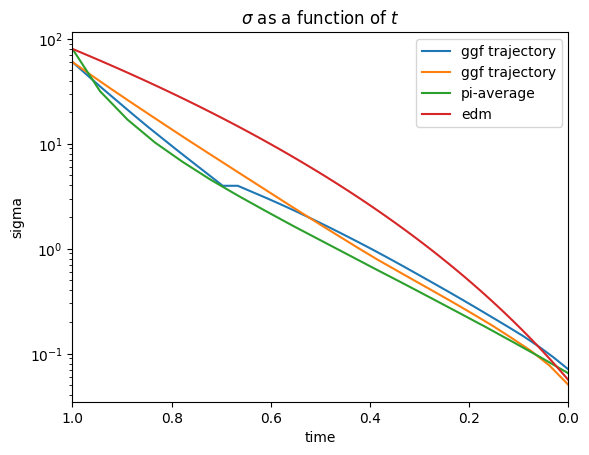

In [28]:
plt.title(r"$\sigma$ as a function of $t$")
plt.plot(torch.linspace(1, 0, len(trajectory_1)), trajectory_1.cpu(), label="ggf trajectory")
plt.plot(torch.linspace(1, 0, len(trajectory_2)), trajectory_2.cpu(), label="ggf trajectory")

# plt.plot(torch.linspace(1, 0, len(sigmas)), torch.log(torch.tensor(sigmas) + torch.tensor(sigmas_std)))
# plt.plot(torch.linspace(1, 0, len(sigmas)), torch.log(torch.tensor(sigmas) - torch.tensor(sigmas_std)))
plt.plot(torch.linspace(1, 0, len(discretisation)), discretisation, label="pi-average")
plt.plot(torch.linspace(1, 0, len(edm_schedule)), edm_schedule, label="edm")

plt.legend()
plt.xlim(1, 0)
plt.xlabel("time")
plt.ylabel("sigma")
plt.yscale("log")

In [10]:
edm_solver = solver_lib.EDMSolver(discretisation, model,S_churn=40, S_min=0.05, S_max=50, S_noise=1.003).to("cuda")
x_edm = edm_solver.solve(noise.clone(), labels)

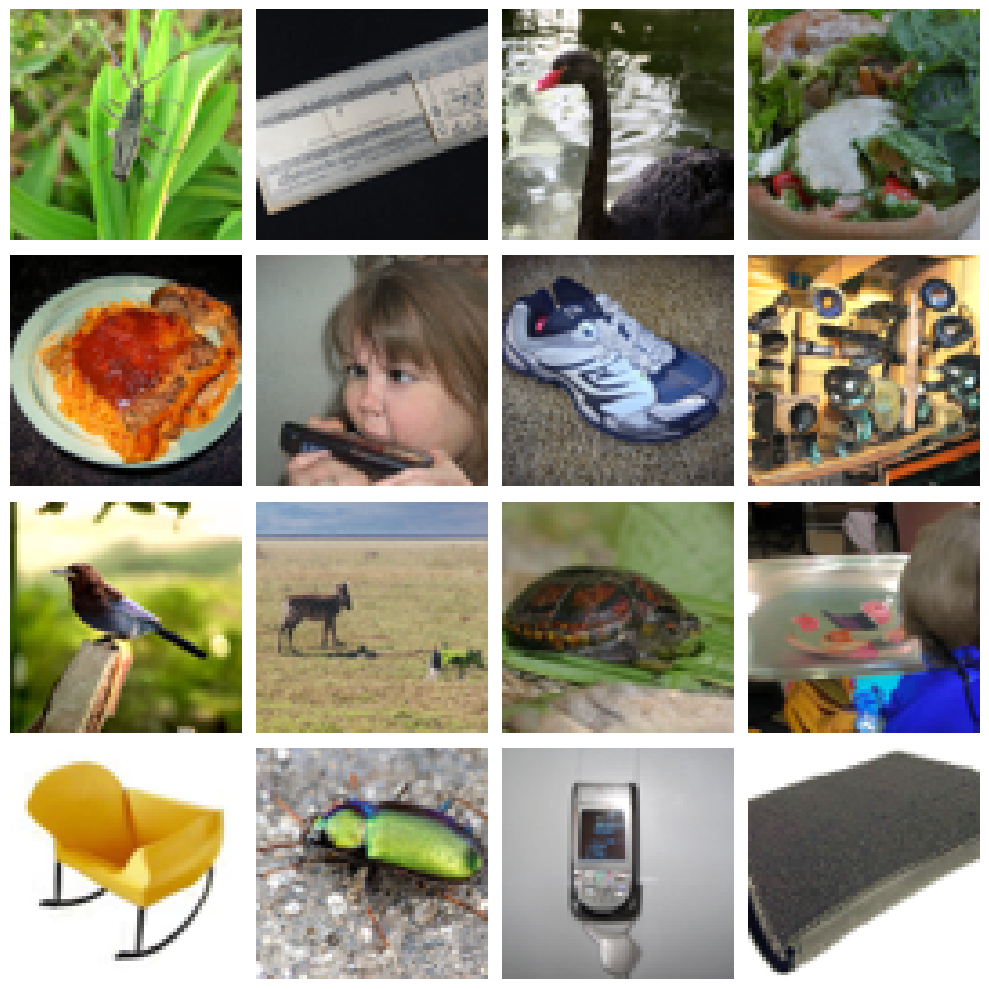

In [11]:
images = encoder.decode(x_edm).permute(0, 2, 3, 1)
plot_images(images.cpu())